# sample2 - 自動微分（Autograd）

PyTorch の **Autograd** は、計算グラフを自動的に構築し、勾配（微分）を自動計算する仕組みです。  
これがニューラルネットワークの学習（バックプロパゲーション）の核心です。

| ステップ | 内容 |
|----------|------|
| 1 | requires_grad と勾配計算 |
| 2 | 計算グラフのイメージ |
| 3 | 勾配の累積と初期化 |
| 4 | 勾配計算を止める（推論時） |
| 5 | 簡単な最急降下法 |

## 1. requires_grad と勾配計算

In [1]:
import torch

# requires_grad=True で勾配追跡を有効化
x = torch.tensor(3.0, requires_grad=True)
print("x:", x)

# y = x^2 の計算
y = x ** 2
print("y = x^2 =", y)

# 逆伝播: dy/dx を計算
y.backward()

# dy/dx = 2x = 2*3 = 6
print("dy/dx =", x.grad)

x: tensor(3., requires_grad=True)
y = x^2 = tensor(9., grad_fn=<PowBackward0>)
dy/dx = tensor(6.)


## 2. 計算グラフのイメージ

In [2]:
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# y = w*x + b （線形変換）
y = w * x + b
print("y = w*x + b =", y)

# loss = y^2
loss = y ** 2
print("loss = y^2 =", loss)

loss.backward()

# 各変数の勾配
print("dloss/dx =", x.grad)  # 2*y*w = 2*7*3 = 42
print("dloss/dw =", w.grad)  # 2*y*x = 2*7*2 = 28
print("dloss/db =", b.grad)  # 2*y*1 = 2*7   = 14

y = w*x + b = tensor(7., grad_fn=<AddBackward0>)
loss = y^2 = tensor(49., grad_fn=<PowBackward0>)
dloss/dx = tensor(42.)
dloss/dw = tensor(28.)
dloss/db = tensor(14.)


## 3. 勾配の累積と初期化

**重要:** PyTorch の勾配は累積されます。学習ループでは毎回 `.zero_grad()` で初期化が必要です。

In [3]:
x = torch.tensor(2.0, requires_grad=True)

# 1回目
y = x ** 2
y.backward()
print("1回目の勾配:", x.grad)  # 4.0

# 2回目（初期化なし → 累積される）
y = x ** 2
y.backward()
print("2回目（累積）:", x.grad)  # 8.0 ← 4+4

# 勾配を初期化してから3回目
x.grad.zero_()
y = x ** 2
y.backward()
print("3回目（初期化後）:", x.grad)  # 4.0

1回目の勾配: tensor(4.)
2回目（累積）: tensor(8.)
3回目（初期化後）: tensor(4.)


## 4. 勾配計算を止める（推論時）

推論（予測）時は勾配計算が不要なので `torch.no_grad()` で止めてメモリ・速度を節約します。

In [4]:
x = torch.tensor(3.0, requires_grad=True)

# 通常: 勾配追跡あり
y = x ** 2
print("通常 - requires_grad:", y.requires_grad)  # True

# no_grad: 勾配追跡なし
with torch.no_grad():
    y2 = x ** 2
    print("no_grad - requires_grad:", y2.requires_grad)  # False

通常 - requires_grad: True
no_grad - requires_grad: False


## 5. 簡単な最急降下法

`y = 2x - 6` の解（x=3）を勾配降下法で求めます。  
これがニューラルネットワーク学習の最もシンプルな形です。

最終 x = 3.0000 (正解: 3.0)
最終 loss = 0.000000


/tmp/ipykernel_36708/1599078454.py:26: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36708/1599078454.py:26: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36708/1599078454.py:26: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36708/1599078454.py:26: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36708/1599078454.py:26: UserWarning: Glyph 21246 (\N{CJK UNIFIED IDEOGRAPH-52FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36708/1599078454.py:26: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_36708/1599078454.py:26: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font

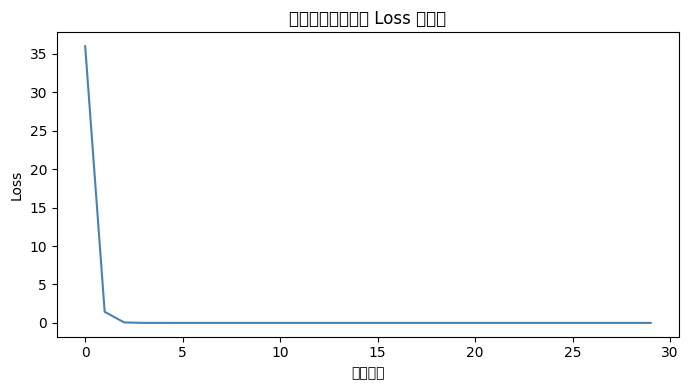

In [5]:
import matplotlib.pyplot as plt

x = torch.tensor(0.0, requires_grad=True)  # 初期値
lr = 0.1   # 学習率
history = []

for step in range(30):
    # loss = (2x - 6)^2  → 最小値は x=3
    loss = (2 * x - 6) ** 2
    history.append(loss.item())

    loss.backward()          # 勾配計算

    with torch.no_grad():
        x -= lr * x.grad     # パラメータ更新
    x.grad.zero_()           # 勾配初期化

print(f"最終 x = {x.item():.4f} (正解: 3.0)")
print(f"最終 loss = {history[-1]:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(history, color='steelblue')
plt.xlabel("ステップ")
plt.ylabel("Loss")
plt.title("勾配降下法による Loss の減少")
plt.tight_layout()
plt.show()